# 00 - Annotation development and validation set extraction

Re-extracts both sets at the **unit level** (SOL + student turns), each row
carrying the full MathDial record of its dialogue. Set membership is pinned
and unchanged; only the extraction schema is new.

- The development set is an **input frame only** (no label columns).
- The validation set carries **empty five-way gold columns** for the human
  annotator, plus an empty thread-table template, per the registered
  validation design (frozen codebook, cross-family five-way, ledger schema).
- All source, membership, and generated set files live in
  `extension/artifacts/annotation_dev_and_val_sets/`.


## Setup

In [23]:
import os
from pathlib import Path

# Walk up to the repo root (folder containing data/annotated).
_here = Path.cwd()
for _c in [_here, *_here.parents]:
    if (_c / "data" / "annotated").exists():
        os.chdir(_c)
        break
else:
    raise FileNotFoundError("Could not find data/annotated above " + str(_here))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from extension.scripts.format_misconception_data import (
    ANNOTATION_COLUMNS,
    FAMILY_ORDER,
    add_annotation_columns,
    build_units,
    family_of,
    has_annotations,
    load_mathdial,
    validate_units,
)

DATA = Path("data/annotated")
SETS_DIR = Path("extension/artifacts/annotation_dev_and_val_sets")
SETS_DIR.mkdir(parents=True, exist_ok=True)
DEV_CSV = SETS_DIR / "development_set_legacy.csv"  # preserved original set (read-only here)
DEV_OUT = SETS_DIR / "development_set.csv"         # supplemented development set
print("working directory:", os.getcwd())


working directory: /Users/tandon.utsav2/Desktop/Experiment_1


## The six misconception families

The student profile collapses to six families. This mapping is the single source
of truth for family membership throughout the notebook.


In [24]:
print("families:", FAMILY_ORDER)


families: ['comprehension', 'principles', 'relevance', 'wrong-operation', 'steps', 'problem-type']


## Part 1: inspect the original development set

`development_set_legacy.csv` preserves the original 55-dialogue membership and
its family coverage, and is read here only for that membership. The final
supplemented membership comes from the pinned `development_set_ids.json` when
that file exists; therefore rerunning the notebook does not redraw an
established set. The previously labelled subset is also identified so coverage
can be profiled for both.


In [25]:
dev = pd.read_csv(DEV_CSV, keep_default_na=False)

# Pinned ids: the definition of the development set.
dev_ids = sorted(dev["dialogue_id"].unique().tolist())
dev_dialogues = dev.drop_duplicates("dialogue_id")[["dialogue_id", "misconception_general"]].copy()
dev_dialogues["family"] = dev_dialogues["misconception_general"].apply(family_of)

# Labelled subset.
labelled_ids = sorted(dev.loc[dev["label"].str.strip() != "", "dialogue_id"].unique().tolist())
n_labelled_turns = int((dev["label"].str.strip() != "").sum())

print(f"development set: {len(dev_ids)} dialogues, {len(dev)} turns")
print(f"labelled: {len(labelled_ids)} dialogues, {n_labelled_turns} turns")
print(f"pinned ids: {dev_ids}")


development set: 55 dialogues, 308 turns
labelled: 0 dialogues, 0 turns
pinned ids: [37, 44, 96, 98, 188, 191, 319, 328, 523, 609, 680, 746, 748, 806, 887, 907, 927, 929, 977, 990, 1036, 1050, 1075, 1090, 1095, 1159, 1269, 1334, 1395, 1412, 1462, 1471, 1493, 1598, 1626, 1654, 1709, 1744, 1745, 1825, 1827, 1862, 1900, 1903, 1926, 1966, 1969, 2057, 2075, 2087, 2142, 2152, 2223, 2226, 2249]


## Part 2: family coverage histogram

The histogram shows how many dialogues each family contributes, for the
original development set and for its previously labelled subset. Uneven
coverage here is what the supplementation step corrects.


full development set, dialogues per family:
family
comprehension       9
principles         11
relevance           5
wrong-operation     9
steps              13
problem-type        8

labelled subset, dialogues per family:
family
comprehension      0
principles         0
relevance          0
wrong-operation    0
steps              0
problem-type       0


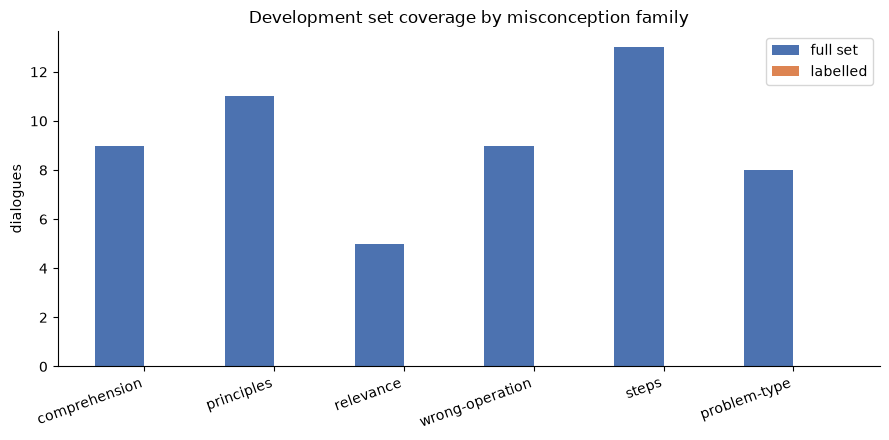

In [26]:
full_counts = (dev_dialogues["family"].value_counts()
                .reindex(FAMILY_ORDER, fill_value=0))
lab_counts = (dev_dialogues[dev_dialogues["dialogue_id"].isin(labelled_ids)]["family"]
              .value_counts().reindex(FAMILY_ORDER, fill_value=0))

print("full development set, dialogues per family:")
print(full_counts.to_string())
print("\nlabelled subset, dialogues per family:")
print(lab_counts.to_string())

x = np.arange(len(FAMILY_ORDER)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, full_counts.values, w, label="full set", color="#4C72B0")
ax.bar(x + w/2, lab_counts.values, w, label="labelled", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=20, ha="right")
ax.set_ylabel("dialogues"); ax.set_title("Development set coverage by misconception family")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


## Part 3: supplement under-represented families

To ensure enough examples per family, each family is topped up to a common
target number of dialogues by drawing from the untouched pool. The draw is
seeded and family-stratified, excludes every id already in the development set,
and (optionally) excludes a sealed held-out set so the two never overlap. Only
the shortfall is drawn: a family already at or above target adds nothing.


In [27]:
# Load the annotated source once; structured columns are parsed on read.
src = load_mathdial(DATA / "mathdial_train_atc.csv")
ID_COL = "index" if "index" in src.columns else src.columns[0]
src["family"] = src["student_profile"].apply(family_of)

def sample_by_family(excluded_ids, target, seed, existing_counts=None):
    """Draw a reproducible, family-balanced set outside `excluded_ids`."""
    available = src[~src[ID_COL].isin(set(excluded_ids))]
    existing_counts = existing_counts or {}
    rng = np.random.default_rng(seed)
    chosen = []
    for family in FAMILY_ORDER:
        have = int(existing_counts.get(family, 0))
        need = max(0, target - have)
        pool = available.loc[available["family"] == family, ID_COL].tolist()
        count = min(need, len(pool))
        picks = rng.choice(pool, size=count, replace=False) if count else []
        chosen.extend(int(dialogue_id) for dialogue_id in picks)
        print(f"  {family:18s} have {have:2d}  need {need:2d}  "
              f"pool {len(pool):3d}  drawing {count:2d}")
    return sorted(set(chosen))

# Development membership is pinned once created; otherwise supplement the original set.
TARGET_PER_FAMILY = 13
SEED = 11
HELDOUT_IDS_PATH = None   # optional JSON list of sealed dialogue ids
DEV_IDS_JSON = SETS_DIR / "development_set_ids.json"

if DEV_IDS_JSON.exists():
    with DEV_IDS_JSON.open() as handle:
        dev_extract_ids = sorted(json.load(handle)["dialogue_ids"])
    chosen = sorted(set(dev_extract_ids) - set(dev_ids))
    print(f"development ids from pinned file: {len(dev_extract_ids)} (no re-draw)")
else:
    excluded = set(dev_ids)
    if HELDOUT_IDS_PATH and Path(HELDOUT_IDS_PATH).exists():
        with Path(HELDOUT_IDS_PATH).open() as handle:
            excluded.update(json.load(handle))
    print(f"target {TARGET_PER_FAMILY} dialogues per family (seed {SEED})")
    chosen = sample_by_family(excluded, TARGET_PER_FAMILY, SEED,
                              full_counts.to_dict())
    dev_extract_ids = sorted(set(dev_ids) | set(chosen))

print(f"new dialogues added to the original set: {len(chosen)}")
print("new ids:", chosen)


development ids from pinned file: 78 (no re-draw)
new dialogues added to the original set: 23
new ids: [59, 163, 280, 308, 329, 547, 634, 852, 1035, 1064, 1143, 1202, 1219, 1420, 1538, 1639, 1830, 1967, 2063, 2090, 2150, 2233, 2236]


### Build the unit rows (the layout)

The shared formatter in `extension/scripts/format_misconception_data.py`
produces one row per **unit**: a `solution` row followed by one row per
student turn. Each row carries a readable spine and then the full MathDial
record.

- **Identity and descriptors.** `dialogue_id`; `turn` (`solution` or
  `turn n`); the native MathDial descriptors `student_profile`,
  `teacher_described_confusion`, `question`, `student_incorrect_solution`.
- **Context and content.** `dialogue_history` holds the exchange before this
  response, ending on the tutor turn that prompts it (empty for the solution
  row); `student_turn_text` holds the unit's own text.
- **Turn-level annotation.** `correct` and `kcs` come from the per-turn ATC
  annotation (guarded against error records). The solution row carries
  `correct=False`, the dataset's by-construction value, and no `kcs`, since
  the source assigns the solution none.
- **Tail.** The remaining MathDial fields copied unchanged, the `family`
  mapping, and `conversation`: the causal prefix rendered as a readable
  transcript (`Tutor:` the problem, `Student (turn 0):` the solution, then
  the dialogue through this row's turn inclusive), so the solution row's
  `conversation` is the problem plus solution and the final row's is the
  full dialogue.


In [28]:
# The shared formatter keeps development solution KCs blank.
dev_units = build_units(src, dev_extract_ids, solution_kcs="blank")
dev_audit = validate_units(
    dev_units, solution_kcs="blank", expected_dialogues=len(dev_extract_ids)
)
print(f"development extraction: {dev_units['dialogue_id'].nunique()} dialogues, "
      f"{len(dev_units)} rows (incl. solution rows)")

_turn_rows = dev_units[dev_units["turn"] != "solution"]
if len(_turn_rows) and (_turn_rows["correct"].astype(str).str.strip() == "").all():
    _raw = src.set_index(ID_COL).loc[dev_extract_ids[0]].get("annotation")
    print("WARNING: correct/kcs empty on every turn row. "
          "Raw annotation sample from the first dialogue:")
    print(repr(_raw)[:600])

# Optional consistency check against completed development annotations.
def to_gold_unit(turn):
    return "SOL" if turn == "solution" else "T" + turn.replace("turn", "").strip()

GOLD = Path("extension/artifacts/fiveway_annotations.csv")
if GOLD.exists():
    gold = pd.read_csv(GOLD)
    gm = gold.groupby("dialogue_id")["unit"].apply(set)
    em = (dev_units.assign(u=dev_units["turn"].map(to_gold_unit))
          .groupby("dialogue_id")["u"].apply(set))
    bad = {int(d): (sorted(em.get(d, set()) - gm[d]), sorted(gm[d] - em.get(d, set())))
           for d in gm.index if gm[d] != em.get(d, set())}
    assert not bad, f"unit mismatch vs gold (extra, missing): {bad}"
    print(f"gold alignment passed: unit sets identical for all {len(gm)} dialogues")
else:
    print("gold file not found at", GOLD, "- alignment check skipped")


development extraction: 78 dialogues, 516 rows (incl. solution rows)
gold file not found at extension/artifacts/fiveway_annotations.csv - alignment check skipped


### Post-extraction coverage

Family coverage of the final supplemented set, plotted beside the original
membership so the supplementation's effect is visible per family.


development dialogues per family (re-extracted):
family
comprehension      13
principles         13
relevance          13
wrong-operation    13
steps              13
problem-type       13

rows: 516 across 78 dialogues (median 6 units per dialogue, incl. solution)


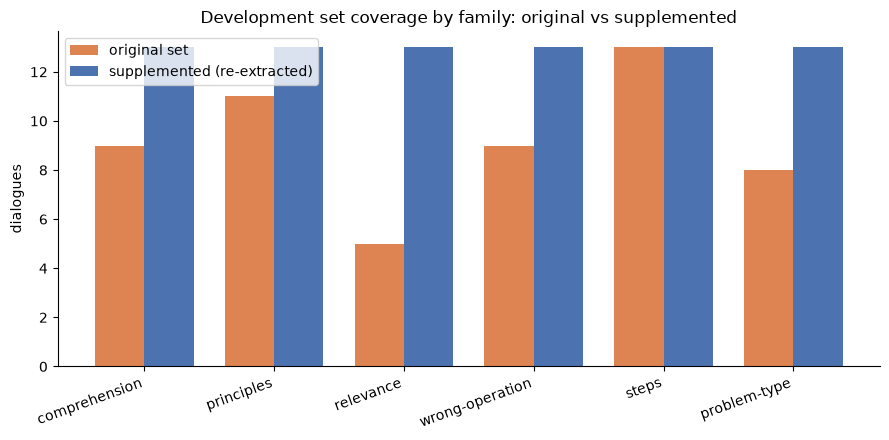

In [29]:
dev_cov = (dev_units.drop_duplicates("dialogue_id")["family"]
           .value_counts().reindex(FAMILY_ORDER, fill_value=0))
print("development dialogues per family (re-extracted):")
print(dev_cov.to_string())

units_per = dev_units.groupby("dialogue_id")["turn"].nunique()
print(f"\nrows: {len(dev_units)} across {dev_units['dialogue_id'].nunique()} "
      f"dialogues (median {int(units_per.median())} units per dialogue, incl. solution)")

x = np.arange(len(FAMILY_ORDER)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, full_counts.values, w, label="original set", color="#DD8452")
ax.bar(x + w/2, dev_cov.values, w, label="supplemented (re-extracted)", color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=20, ha="right")
ax.set_ylabel("dialogues")
ax.set_title("Development set coverage by family: original vs supplemented")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


### Save the re-extracted development set

Input frame only: no label columns (the development gold lives in the
annotation schema files). The pinned id list is rewritten unchanged.


In [30]:
WRITE = True

if WRITE:
    dev_units.to_csv(DEV_OUT, index=False)
    with DEV_IDS_JSON.open("w") as handle:
        json.dump({"seed": SEED, "target_per_family": TARGET_PER_FAMILY,
                   "dialogue_ids": dev_extract_ids}, handle, indent=2)
    print(f"written {DEV_OUT} ({len(dev_units)} unit rows) and "
          f"development_set_ids.json ({len(dev_extract_ids)} ids)")
else:
    print("dry run: nothing written. Set WRITE = True to persist.")


written extension/artifacts/annotation_dev_and_val_sets/development_set.csv (516 unit rows) and development_set_ids.json (78 ids)


## Part 4: the validation set

Used to test LLM annotation under the **frozen** codebook against a human
gold standard: both annotators produce cross-family five-way labels per unit
plus the thread table of the ledger schema, and origin-family agreement is
the headline figure. Membership is pinned: if the pinned id file exists it is
reused verbatim (the set's identity survives schema changes); only if it is
absent is the family-stratified draw run, excluding every development
dialogue (asserted).


In [31]:
VAL_TARGET_PER_FAMILY = 13
VAL_SEED = 23
VAL_IDS_JSON = SETS_DIR / "validation_set_ids.json"

dev_id_set = set(dev_extract_ids)

if VAL_IDS_JSON.exists():
    with VAL_IDS_JSON.open() as handle:
        val_chosen = sorted(json.load(handle)["dialogue_ids"])
    print(f"validation ids from pinned file: {len(val_chosen)} (no re-draw)")
else:
    print(f"validation target {VAL_TARGET_PER_FAMILY} per family (seed {VAL_SEED})")
    val_chosen = sample_by_family(dev_id_set, VAL_TARGET_PER_FAMILY, VAL_SEED)

overlap = set(val_chosen) & dev_id_set
assert not overlap, f"validation overlaps development: {sorted(overlap)}"
print(f"validation dialogues: {len(val_chosen)}; no-overlap check passed")


validation ids from pinned file: 78 (no re-draw)
validation dialogues: 78; no-overlap check passed


### Validation family coverage

Dialogues per native profile family in the drawn (or pinned) validation set.
The draw is family-stratified, so bars at or near the per-family target are
expected; a shorter bar means the untouched pool ran out for that family.


validation dialogues per family:
family
comprehension      13
principles         13
relevance          13
wrong-operation    13
steps              13
problem-type       13


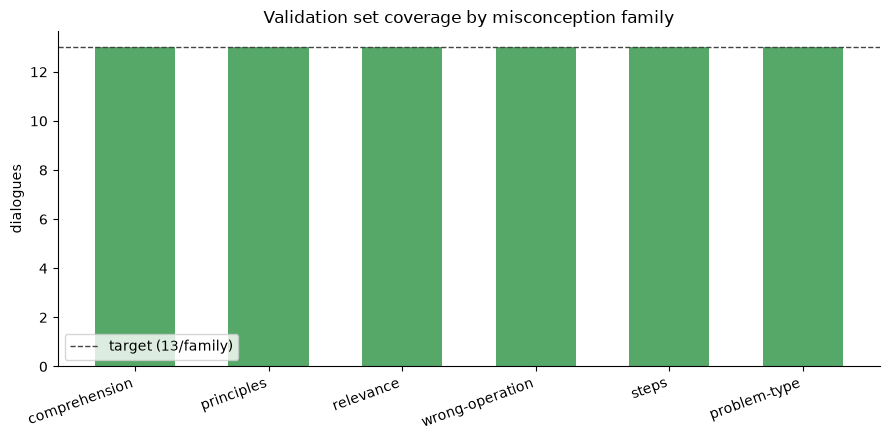

In [32]:
val_fam = (src.set_index(ID_COL).loc[val_chosen, "family"]
           .value_counts().reindex(FAMILY_ORDER, fill_value=0))
print("validation dialogues per family:")
print(val_fam.to_string())

x = np.arange(len(FAMILY_ORDER))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x, val_fam.values, 0.6, color="#55A868")
ax.axhline(VAL_TARGET_PER_FAMILY, color="#444444", linewidth=1,
           linestyle="--", label=f"target ({VAL_TARGET_PER_FAMILY}/family)")
ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=20, ha="right")
ax.set_ylabel("dialogues")
ax.set_title("Validation set coverage by misconception family")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


### Build and save the validation set — annotation columns explained

The human-gold surface has three parts: five pure judgment columns, five
parallel source columns, and one dialogue-level metadata column. The LLM
never touches this file.

**Judgment columns** (`comprehension`, `relevance`, `principles`,
`wrong_operation`, `steps`) — exactly one of `P`, `A`, `N` per cell.
Nothing else goes in these columns. A blank cell means unannotated (visible
progress), not `N`.

**Source columns** (`comprehension_src`, `relevance_src`, `principles_src`,
`wrong_operation_src`, `steps_src`) — thread attribution for the matching
judgment cell, with defaults chosen so most cells stay blank:

- `P` with blank src — allowed only when the dialogue has exactly one thread
  of that family; the attribution is inferred. If two same-family threads
  exist, the src cell is required (`S1` or `S1,S2` for layered exhibition).
- `A` with blank src — thread-independent credit (the symmetric and
  re-articulation standards; the common case).
- `A` with src filled (`S1`) — a *resolution*: the student's own act commits
  the corrected counterpart of that thread's token, per the codebook's
  resolution step (named fixes executed, supplied corrected operands, and
  extensions of revealed corrections do not qualify).
- `N` — src stays blank always.

**`dialogue_threads`** — the misconception metadata for the whole dialogue,
one cell, present on every row for readability while annotating. The
**solution row is authoritative**: the assembly script reads it from there,
broadcasts it down, and warns if any turn row carries a different non-empty
value. Grammar, one thread per segment, segments separated by `||`:

```
S1: family=comprehension; belief=<one line>; signature=<quantity/operand/omission + role>;
    origin=solution; kind=initial; resolved_at=turn 5 || S2: family=...
```

- `family` — one of the five.
- `belief` — the enacted belief, one line, stated once here.
- `signature` — what re-emergence matching runs on.
- `origin` — `solution` or `turn n`.
- `kind` — `initial` | `re-attribution` | `post-expiry`.
- `resolved_at` — the resolving turn, omitted if the thread is never
  resolved. `resolved_by_end` is derived: `resolved_at` is set and no later
  turn's cell cites the thread as `P`.

Exhibition histories are derived from the grid: a thread's exhibitions are
the turns whose judgment cell is `P` and whose src (explicit or inferred)
includes its id. A resolution may fall at a turn whose judgment cell is `P`
for a same-family sibling thread; the cell then records the sibling's
exhibition and the resolution is carried by `resolved_at` alone, so
consistency checks verify resolutions against `dialogue_threads`, never by
scanning for `A` cells. `note` remains for genuine residue (event tags where
salient, echo/dictation observations). Writes are guarded: a file containing
any annotation is never overwritten.


In [33]:
val_units = add_annotation_columns(
    build_units(src, val_chosen, solution_kcs="blank")
)
val_audit = validate_units(
    val_units, solution_kcs="blank", expected_dialogues=len(val_chosen)
)

print(f"validation set: {val_units['dialogue_id'].nunique()} dialogues, "
      f"{len(val_units)} rows")
_vc = val_units.drop_duplicates("dialogue_id")["family"]
print("validation dialogues per family:")
print(_vc.value_counts().reindex(FAMILY_ORDER, fill_value=0).to_string())

WRITE_VAL = True
VAL_OUT = SETS_DIR / "validation_set.csv"

if WRITE_VAL:
    if has_annotations(VAL_OUT):
        print(f"REFUSING to overwrite {VAL_OUT}: it contains annotations.")
    else:
        val_units.to_csv(VAL_OUT, index=False)
        with VAL_IDS_JSON.open("w") as handle:
            json.dump({"seed": VAL_SEED,
                       "target_per_family": VAL_TARGET_PER_FAMILY,
                       "dialogue_ids": val_chosen,
                       "excludes_development_ids": sorted(dev_id_set)},
                      handle, indent=2)
        print(f"written {VAL_OUT} ({len(val_units)} rows) and validation_set_ids.json")
else:
    print("dry run: nothing written. Set WRITE_VAL = True to persist.")


validation set: 78 dialogues, 544 rows
validation dialogues per family:
family
comprehension      13
principles         13
relevance          13
wrong-operation    13
steps              13
problem-type       13
written extension/artifacts/annotation_dev_and_val_sets/validation_set.csv (544 rows) and validation_set_ids.json


## Part 5: format the complete training and test sets

The released annotated MathDial train and test splits are expanded with the
same unit-row schema and empty misconception-annotation columns as the
validation set. All source dialogues are retained at this formatting stage;
paper-specific filtering belongs downstream. Consequently, the 18 train and
7 test dialogues with failed ATC annotations remain present, but their real
turns have blank `correct`/`kcs` values.

The deliberate difference is the synthetic `solution` (turn 0) row:

- `correct=False`, because MathDial defines it as an incorrect solution;
- `kcs` is the de-duplicated union of KCs on all annotated turns in that
  dialogue, preserving dialogue order and first-appearance order.

This union is a **retrospective dialogue-level annotation**. If the solution
row is used as a sequential model input, it reveals which KCs appear later in
the dialogue; that is an intentional modelling extension, not the paper's
original BKT input. The exports are written to `data/misconception/`.


In [34]:
MISCONCEPTION_DIR = Path("data/misconception")
MISCONCEPTION_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_OUT = MISCONCEPTION_DIR / "mathdial_train.csv"
TEST_OUT = MISCONCEPTION_DIR / "mathdial_test.csv"

train_source = src
test_source = load_mathdial(DATA / "mathdial_test_atc.csv")

train_units = add_annotation_columns(
    build_units(train_source, solution_kcs="dialogue_union")
)
test_units = add_annotation_columns(
    build_units(test_source, solution_kcs="dialogue_union")
)

split_audits = {}
for split, source_frame, unit_frame in [
    ("train", train_source, train_units),
    ("test", test_source, test_units),
]:
    audit = validate_units(
        unit_frame,
        solution_kcs="dialogue_union",
        expected_dialogues=len(source_frame),
    )
    audit["failed_annotations_retained"] = int(
        source_frame["annotation"].map(
            lambda value: isinstance(value, dict) and "error" in value
        ).sum()
    )
    split_audits[split] = audit

print(pd.DataFrame(split_audits).T.to_string())

WRITE_MISCONCEPTION = True
for split, unit_frame, output_path in [
    ("train", train_units, TRAIN_OUT),
    ("test", test_units, TEST_OUT),
]:
    if not WRITE_MISCONCEPTION:
        print(f"dry run: {split} not written")
    elif has_annotations(output_path):
        print(f"REFUSING to overwrite {output_path}: it contains annotations.")
    else:
        unit_frame.to_csv(output_path, index=False)
        print(f"written {output_path} ({len(unit_frame)} rows)")


       dialogues   rows  solution_rows  solutions_with_kcs  failed_annotations_retained
train       2253  15609           2253                2235                           18
test         595   3902            595                 588                            7
written data/misconception/mathdial_train.csv (15609 rows)
written data/misconception/mathdial_test.csv (3902 rows)


## Summary

- Membership pinned for both sets; the draw runs only when a pinned id file
  is absent; no-overlap asserted either way.
- One imported, reusable formatter produces one row per unit (a `solution`
  row plus one per student turn), reconstructs causal context, applies ATC
  labels, and validates the schema and turn ordering.
- Development: no label columns; gold lives in the schema files; unit sets
  asserted equal to `fiveway_annotations.csv`.
- Validation: pure three-value judgment columns, parallel per-family source
  columns with blank-defaults (P blank = inferred single thread; A blank =
  independent credit; A with id = resolution under the codebook's
  act-for-act rule), and one `dialogue_threads` metadata cell per row with
  the solution row authoritative. Exhibitions and `resolved_by_end` are
  derived from the grid and `resolved_at`.
- Full train/test exports use that validation surface, retain every source
  dialogue, and give the incorrect solution row the ordered union of all KCs
  observed later in its dialogue. Annotated files are never overwritten.
